In [1]:
# !pip install kagglehub


In [2]:
from sklearn.model_selection import GridSearchCV
import pandas as pd
import os

# Cargar el CSV desde el directorio local en lugar de kagglehub
csv_path = 'WA_Fn-UseC_-Telco-Customer-Churn.csv'
record_set_df = pd.read_csv(csv_path)

# Mostrar los primeros registros
record_set_df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Importar Librerías

In [3]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

print("Librerías importadas exitosamente.")


Librerías importadas exitosamente.


# Cargar Conjunto de Datos

In [4]:
df = pd.read_csv(csv_path)



print("Conjunto de datos cargado exitosamente.")

print("\nPrimeras Cinco Filas:")
print(df.head())

print("\nForma del Conjunto de Datos (Filas, Columnas):")
print(df.shape)

Conjunto de datos cargado exitosamente.

Primeras Cinco Filas:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   


# Explorar Conjunto de Datos

In [5]:
print("\nNombres de las Columnas:")
print(df.columns)

print("\nTipos de Datos:")
print(df.dtypes)

print("\nValores Nulos:")
print(df.isnull().sum())

print("\nEstadísticas Descriptivas:")
print(df.describe())


Nombres de las Columnas:
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

Tipos de Datos:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn              

# Limpieza de Datos

In [6]:
# Convertir TotalCharges (Cargos Totales) a formato numérico
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

# Eliminar valores nulos (missing values)
df.dropna(inplace=True)

# Eliminar la columna customerID (no es útil para predicción)
df.drop("customerID", axis=1, inplace=True)

print("Limpieza de datos completada.")

print("\nNueva Forma del Conjunto de Datos:")
print(df.shape)

Limpieza de datos completada.

Nueva Forma del Conjunto de Datos:
(7032, 20)


# Codificación de Variables

In [7]:
# Codificar la variable objetivo (Churn) a 1 y 0
df["Churn"] = df["Churn"].map({
    "Yes": 1,
    "No": 0
})

# Convertir las variables categóricas usando variables dummy (One-Hot Encoding)
df = pd.get_dummies(
    df,
    drop_first=True
)

print("Codificación completada.")

print("\nPrimeras Cinco Filas:")
print(df.head())

Codificación completada.

Primeras Cinco Filas:
   SeniorCitizen  tenure  MonthlyCharges  TotalCharges  Churn  gender_Male  \
0              0       1           29.85         29.85      0        False   
1              0      34           56.95       1889.50      0         True   
2              0       2           53.85        108.15      1         True   
3              0      45           42.30       1840.75      0         True   
4              0       2           70.70        151.65      1        False   

   Partner_Yes  Dependents_Yes  PhoneService_Yes  \
0         True           False             False   
1        False           False              True   
2        False           False              True   
3        False           False             False   
4        False           False              True   

   MultipleLines_No phone service  ...  StreamingTV_No internet service  \
0                            True  ...                            False   
1                   

# Definir Características (X) y Variable Objetivo (y)

In [8]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print("Características y variable objetivo definidas.")

print("\nForma de Características (X):")
print(X.shape)

print("\nForma del Objetivo (y):")
print(y.shape)

Características y variable objetivo definidas.

Forma de Características (X):
(7032, 30)

Forma del Objetivo (y):
(7032,)


# Dividir Conjunto de Datos en Entrenamiento y Prueba

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("División de datos en entrenamiento y prueba completada.")

print("\nForma del Conjunto de Entrenamiento:")
print(X_train.shape)

print("\nForma del Conjunto de Prueba:")
print(X_test.shape)

División de datos en entrenamiento y prueba completada.

Forma del Conjunto de Entrenamiento:
(5625, 30)

Forma del Conjunto de Prueba:
(1407, 30)


# Escalado de Características

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Escalado de características completado.")

Escalado de características completado.


# Optimización de Hiperparámetros
Utilizamos `GridSearchCV` para encontrar los mejores hiperparámetros de cada modelo **antes** de entrenarlo con los datos.
Esto garantiza que cada modelo se evalúe con su configuración óptima.

In [11]:
# --- Optimización de Regresión Logística ---
from sklearn.model_selection import GridSearchCV

lr_base = LogisticRegression(max_iter=1000, random_state=42)
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear']
}

lr_grid_search = GridSearchCV(
    estimator=lr_base,
    param_grid=lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

lr_grid_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros LR:", lr_grid_search.best_params_)
print("Mejor F1-Score LR (CV):", round(lr_grid_search.best_score_, 4))


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejores hiperparámetros LR: {'C': 10, 'solver': 'lbfgs'}
Mejor F1-Score LR (CV): 0.5966


In [12]:
# --- Optimización de KNN ---
knn_base = KNeighborsClassifier()
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_grid_search = GridSearchCV(
    estimator=knn_base,
    param_grid=knn_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

knn_grid_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros KNN:", knn_grid_search.best_params_)
print("Mejor F1-Score KNN (CV):", round(knn_grid_search.best_score_, 4))


Fitting 5 folds for each of 24 candidates, totalling 120 fits
Mejores hiperparámetros KNN: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}
Mejor F1-Score KNN (CV): 0.5771


In [13]:
# --- Optimización de Random Forest ---
rf_base = RandomForestClassifier(random_state=42)
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

rf_grid_search.fit(X_train_scaled, y_train)

print("Mejores hiperparámetros RF:", rf_grid_search.best_params_)
print("Mejor F1-Score RF (CV):", round(rf_grid_search.best_score_, 4))


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparámetros RF: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}
Mejor F1-Score RF (CV): 0.588


In [14]:
# --- Resumen de la optimización ---
print("="*60)
print("RESUMEN DE OPTIMIZACIÓN DE HIPERPARÁMETROS")
print("="*60)
print(f"Logistic Regression: {lr_grid_search.best_params_}  ->  F1(CV): {lr_grid_search.best_score_:.4f}")
print(f"KNN:                 {knn_grid_search.best_params_}  ->  F1(CV): {knn_grid_search.best_score_:.4f}")
print(f"Random Forest:       {rf_grid_search.best_params_}  ->  F1(CV): {rf_grid_search.best_score_:.4f}")
print("="*60)


RESUMEN DE OPTIMIZACIÓN DE HIPERPARÁMETROS
Logistic Regression: {'C': 10, 'solver': 'lbfgs'}  ->  F1(CV): 0.5966
KNN:                 {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}  ->  F1(CV): 0.5771
Random Forest:       {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}  ->  F1(CV): 0.5880


# Entrenamiento de los Modelos con Hiperparámetros Óptimos
Ahora entrenamos cada modelo usando los mejores hiperparámetros encontrados por `GridSearchCV`.
Cada `GridSearchCV` ya reentrenó el mejor estimador con todos los datos de entrenamiento, así que extraemos directamente `best_estimator_`.

# MODELO DE REGRESIÓN LOGÍSTICA (Optimizado)

In [15]:
# Extraemos el mejor modelo de Regresión Logística
lr_model = lr_grid_search.best_estimator_

lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Modelo de Regresión Logística optimizado y evaluado.")
print("Hiperparámetros:", lr_grid_search.best_params_)


Modelo de Regresión Logística optimizado y evaluado.
Hiperparámetros: {'C': 10, 'solver': 'lbfgs'}


# EVALUACIÓN DE REGRESIÓN LOGÍSTICA

In [16]:
print(classification_report(
    y_test,
    lr_preds
))

lr_accuracy = accuracy_score(
    y_test,
    lr_preds
)

lr_precision = precision_score(
    y_test,
    lr_preds
)

lr_recall = recall_score(
    y_test,
    lr_preds
)

lr_f1 = f1_score(
    y_test,
    lr_preds
)

lr_auc = roc_auc_score(
    y_test,
    lr_probs
)

print("\nAccuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall:", lr_recall)
print("F1 Score:", lr_f1)
print("ROC-AUC:", lr_auc)

              precision    recall  f1-score   support

           0       0.85      0.88      0.87      1033
           1       0.64      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.74      0.73      0.74      1407
weighted avg       0.79      0.80      0.80      1407


Accuracy: 0.8002842928216063
Precision: 0.6388059701492538
Recall: 0.5721925133689839
F1 Score: 0.6036671368124118
ROC-AUC: 0.8351835938106651


# VISUALIZACIÓN DE REGRESIÓN LOGÍSTICA

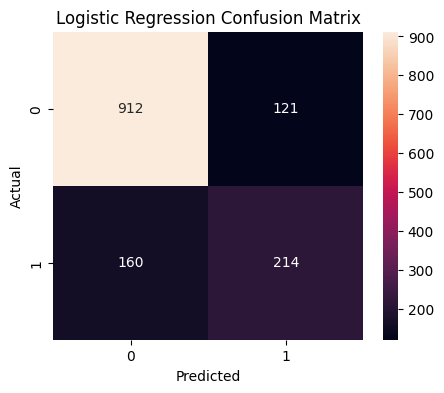

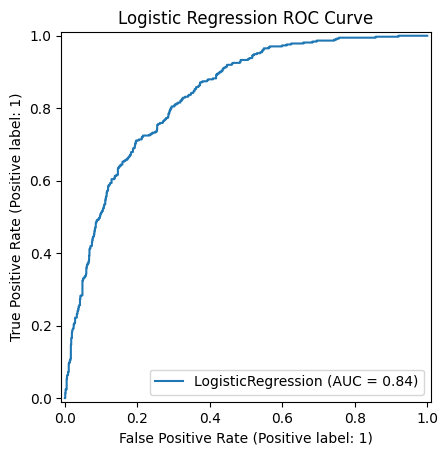

In [17]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    confusion_matrix(y_test, lr_preds),
    annot=True,
    fmt="d"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(
    lr_model,
    X_test_scaled,
    y_test
)

plt.title("Logistic Regression ROC Curve")

plt.show()

# MODELO KNN (K-Vecinos Más Cercanos) (Optimizado)

In [18]:
# Extraemos el mejor modelo KNN
knn_model = knn_grid_search.best_estimator_

knn_preds = knn_model.predict(X_test_scaled)
knn_probs = knn_model.predict_proba(X_test_scaled)[:, 1]

print("Modelo KNN optimizado y evaluado.")
print("Hiperparámetros:", knn_grid_search.best_params_)


Modelo KNN optimizado y evaluado.
Hiperparámetros: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}


# EVALUACIÓN DE KNN

In [19]:
print(classification_report(
    y_test,
    knn_preds
))

knn_accuracy = accuracy_score(
    y_test,
    knn_preds
)

knn_precision = precision_score(
    y_test,
    knn_preds
)

knn_recall = recall_score(
    y_test,
    knn_preds
)

knn_f1 = f1_score(
    y_test,
    knn_preds
)

knn_auc = roc_auc_score(
    y_test,
    knn_probs
)

print("\nAccuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall:", knn_recall)
print("F1 Score:", knn_f1)
print("ROC-AUC:", knn_auc)

              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.57      0.57      0.57       374

    accuracy                           0.77      1407
   macro avg       0.71      0.71      0.71      1407
weighted avg       0.77      0.77      0.77      1407


Accuracy: 0.7718550106609808
Precision: 0.5710455764075067
Recall: 0.56951871657754
F1 Score: 0.570281124497992
ROC-AUC: 0.8124485559426622


# VISUALIZACIÓN DE KNN

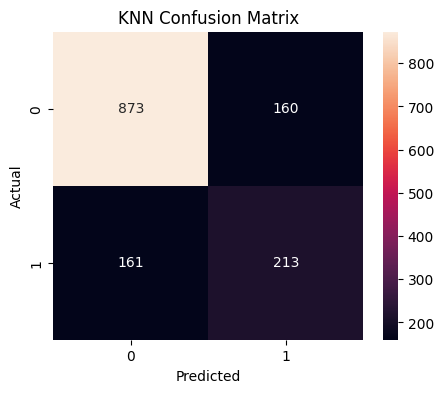

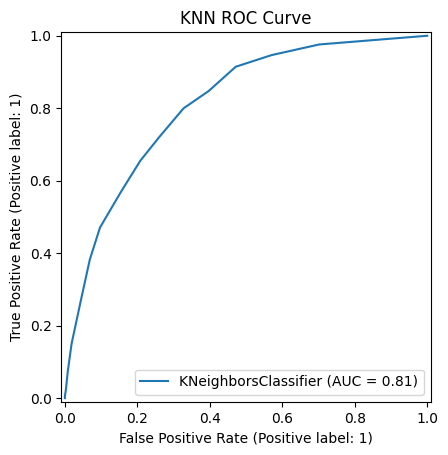

In [20]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    confusion_matrix(y_test, knn_preds),
    annot=True,
    fmt="d"
)

plt.title("KNN Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(
    knn_model,
    X_test_scaled,
    y_test
)

plt.title("KNN ROC Curve")

plt.show()

# MODELO RANDOM FOREST (Bosque Aleatorio) (Optimizado)

In [21]:
# Extraemos el mejor modelo de Random Forest
rf_model = rf_grid_search.best_estimator_

rf_preds = rf_model.predict(X_test_scaled)
rf_probs = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Modelo Random Forest optimizado y evaluado.")
print("Hiperparámetros:", rf_grid_search.best_params_)


Modelo Random Forest optimizado y evaluado.
Hiperparámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}


# EVALUACIÓN DE RANDOM FOREST

In [22]:
print(classification_report(
    y_test,
    rf_preds
))

rf_accuracy = accuracy_score(
    y_test,
    rf_preds
)

rf_precision = precision_score(
    y_test,
    rf_preds
)

rf_recall = recall_score(
    y_test,
    rf_preds
)

rf_f1 = f1_score(
    y_test,
    rf_preds
)

rf_auc = roc_auc_score(
    y_test,
    rf_probs
)

print("\nAccuracy:", rf_accuracy)
print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1 Score:", rf_f1)
print("ROC-AUC:", rf_auc)

              precision    recall  f1-score   support

           0       0.84      0.90      0.86      1033
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.72      1407
weighted avg       0.78      0.79      0.79      1407


Accuracy: 0.7938877043354655
Precision: 0.64
Recall: 0.5133689839572193
F1 Score: 0.56973293768546
ROC-AUC: 0.8339890563283308


# VISUALIZACIÓN DE RANDOM FOREST

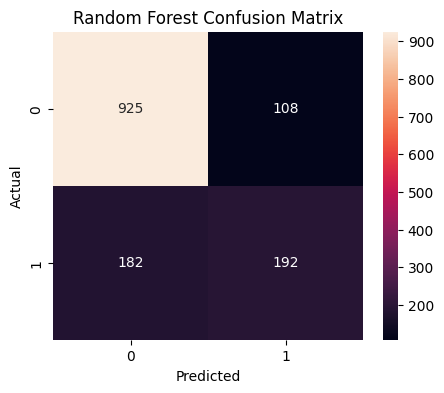

c:\Users\ASUS TUF\Documents\Proyectos\Investigacion\ETL-POBREZA-ALDO\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


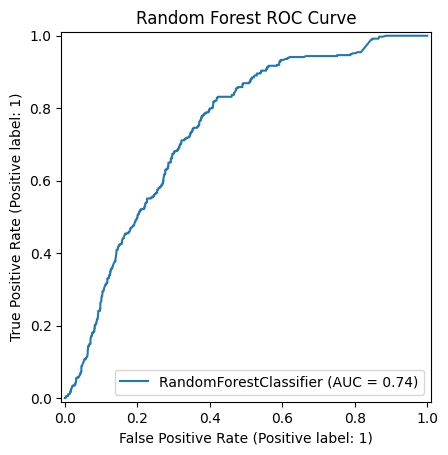

In [23]:
# Matriz de Confusión
plt.figure(figsize=(5, 4))

sns.heatmap(
    confusion_matrix(y_test, rf_preds),
    annot=True,
    fmt="d"
)

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ROC Curve
RocCurveDisplay.from_estimator(
    rf_model,
    X_test,
    y_test
)

plt.title("Random Forest ROC Curve")

plt.show()

# IMPORTANCIA DE LAS VARIABLES (FEATURE IMPORTANCE)


Top 10 Características Más Importantes (Random Forest Optimizado):
                           Feature  Importance
1                           tenure    0.200036
3                     TotalCharges    0.149918
2                   MonthlyCharges    0.123404
10     InternetService_Fiber optic    0.073203
25               Contract_Two year    0.056114
28  PaymentMethod_Electronic check    0.053782
24               Contract_One year    0.036224
13              OnlineSecurity_Yes    0.034499
19                 TechSupport_Yes    0.026673
26            PaperlessBilling_Yes    0.019816


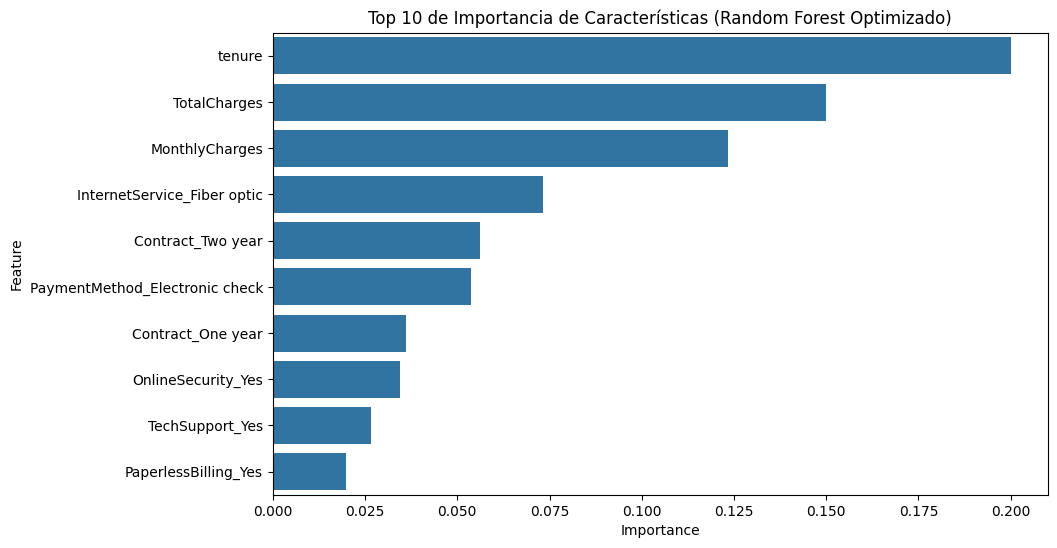

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 10 Características Más Importantes (Random Forest Optimizado):")
print(feature_importance.head(10))

plt.figure(figsize=(10, 6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance.head(10)
)

plt.title("Top 10 de Importancia de Características (Random Forest Optimizado)")
plt.show()


# Tabla de Comparación Final de Modelos

In [25]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        knn_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        knn_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        knn_recall,
        rf_recall
    ],
    "F1 Score": [
        lr_f1,
        knn_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        knn_auc,
        rf_auc
    ]
})

print("\n" + "="*70)
print("TABLA DE COMPARACIÓN FINAL DE MODELOS")
print("="*70)
print(results.to_string(index=False))
print("="*70)

# Identificar el mejor modelo por F1-Score
best_idx = results['F1 Score'].idxmax()
best_model_name = results.loc[best_idx, 'Model']
print(f"\n>>> Mejor modelo según F1-Score: {best_model_name} ({results.loc[best_idx, 'F1 Score']:.4f})")



TABLA DE COMPARACIÓN FINAL DE MODELOS
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression  0.800284   0.638806 0.572193  0.603667 0.835184
                KNN  0.771855   0.571046 0.569519  0.570281 0.812449
      Random Forest  0.793888   0.640000 0.513369  0.569733 0.833989

>>> Mejor modelo según F1-Score: Logistic Regression (0.6037)


# Guardar Resultados en un Archivo CSV

In [26]:
results.to_csv(
    "model_results.csv",
    index=False
)

print("Resultados guardados exitosamente.")

Resultados guardados exitosamente.


# Explicación del Mejor Modelo con SHAP (SHapley Additive exPlanations)
SHAP nos ayuda a interpretar el **mejor modelo** seleccionado a partir de la tabla de comparación,
mostrando cómo cada característica contribuye a la predicción.

Se selecciona automáticamente el modelo con mejor **F1-Score** para el análisis SHAP.

In [27]:
# Instalar shap si no está disponible (descomentar la siguiente línea)
# !pip install shap
import shap

# Determinar cuál es el mejor modelo según F1-Score
best_idx = results['F1 Score'].idxmax()
best_model_name = results.loc[best_idx, 'Model']

# Mapear nombre del modelo al estimador
model_map = {
    'Logistic Regression': lr_model,
    'KNN': knn_model,
    'Random Forest': rf_model
}

best_model = model_map[best_model_name]
print(f"Modelo seleccionado para SHAP: {best_model_name}")

# Convertimos los datos a DataFrames para retener los nombres de las columnas
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)

# Seleccionar el explainer adecuado según el tipo de modelo
if best_model_name == 'Random Forest':
    explainer = shap.TreeExplainer(best_model)
    shap_values_raw = explainer.shap_values(X_test_scaled_df)
    # TreeExplainer devuelve una lista [class0, class1] para clasificación binaria
    if isinstance(shap_values_raw, list):
        shap_vals_class1 = shap_values_raw[1]
    else:
        shap_vals_class1 = shap_values_raw
    shap_data = X_test_scaled_df

elif best_model_name == 'Logistic Regression':
    # Para Logistic Regression usamos LinearExplainer
    explainer = shap.LinearExplainer(best_model, X_train_scaled_df)
    shap_vals_class1 = explainer.shap_values(X_test_scaled_df)
    # LinearExplainer devuelve directamente los valores para la clase positiva
    if isinstance(shap_vals_class1, list):
        shap_vals_class1 = shap_vals_class1[1]
    shap_data = X_test_scaled_df

else:  # KNN
    # Para KNN usamos KernelExplainer con un subset por eficiencia
    background = shap.sample(X_train_scaled_df, 100, random_state=42)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    X_test_subset = X_test_scaled_df.iloc[:100]
    shap_values_raw = explainer.shap_values(X_test_subset)
    if isinstance(shap_values_raw, list):
        shap_vals_class1 = shap_values_raw[1]
    else:
        shap_vals_class1 = shap_values_raw
    shap_data = X_test_subset

print(f"Shape SHAP values: {shap_vals_class1.shape}")
print(f"Shape data:        {shap_data.shape}")
print("Valores SHAP calculados exitosamente.")


Modelo seleccionado para SHAP: Logistic Regression
Shape SHAP values: (1407, 30)
Shape data:        (1407, 30)
Valores SHAP calculados exitosamente.



SHAP Summary Plot para: Logistic Regression


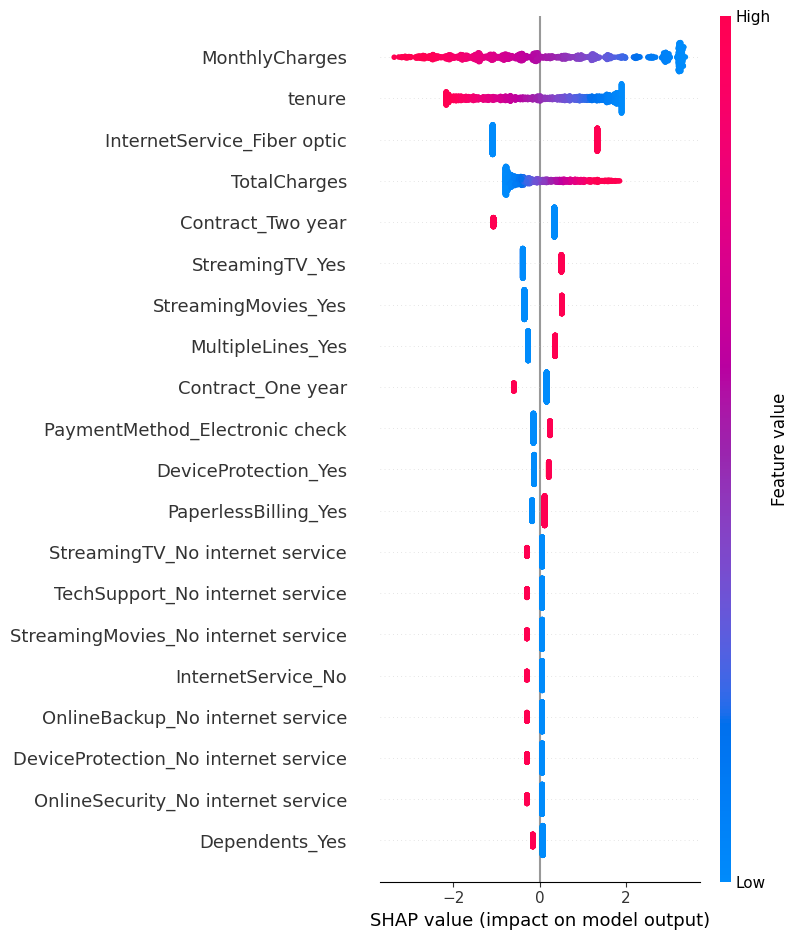

In [28]:
# --- SHAP Summary Plot (Beeswarm) ---
print(f"\nSHAP Summary Plot para: {best_model_name}")
shap.summary_plot(shap_vals_class1, shap_data, show=True)



SHAP Bar Plot para: Logistic Regression


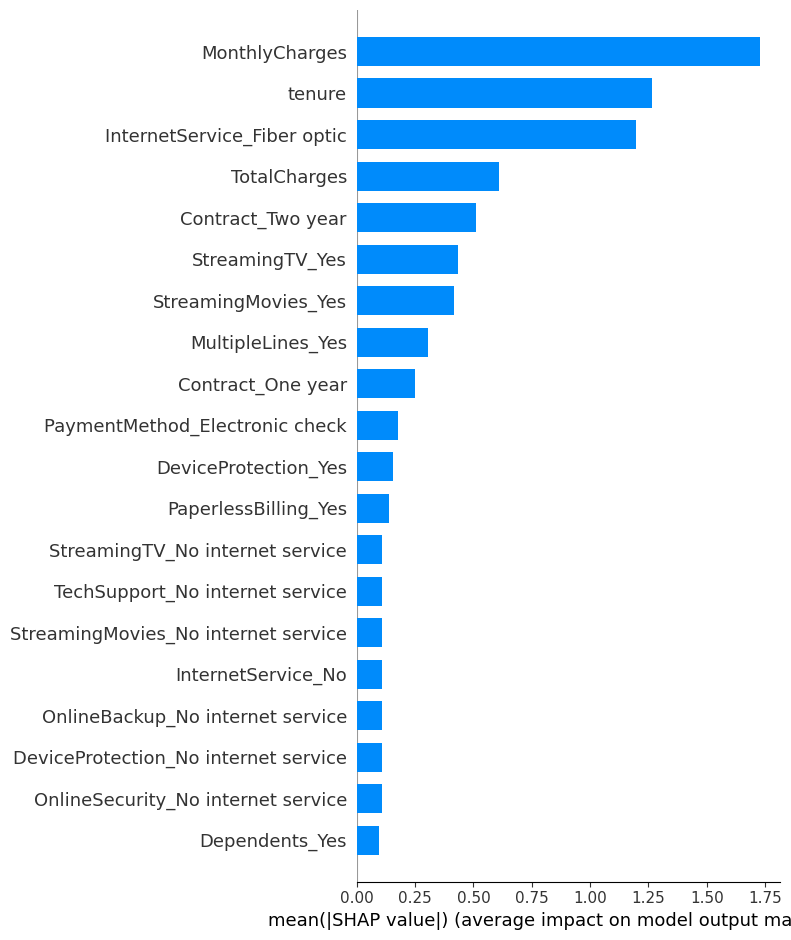

In [29]:
# --- SHAP Bar Plot (importancia media) ---
print(f"\nSHAP Bar Plot para: {best_model_name}")
shap.summary_plot(shap_vals_class1, shap_data, plot_type="bar", show=True)


# Exportación del Modelo y Escalador
Guardamos el mejor modelo optimizado y el escalador de variables en archivos `.pkl` utilizando la librería `joblib`.
Esto permite que el modelo sea cargado posteriormente desde una aplicación web o API en el servidor de producción.

In [30]:
import joblib

# Exportamos el mejor modelo
joblib.dump(best_model, 'best_model.pkl')
print(f"Mejor modelo ({best_model_name}) exportado como 'best_model.pkl'")

# Exportamos el escalador
joblib.dump(scaler, 'scaler.pkl')
print("Escalador exportado como 'scaler.pkl'")

print("\nModelo y escalador exportados exitosamente como archivos .pkl")


Mejor modelo (Logistic Regression) exportado como 'best_model.pkl'
Escalador exportado como 'scaler.pkl'

Modelo y escalador exportados exitosamente como archivos .pkl


# Conclusión Final
Con base en la **optimización de hiperparámetros** realizada mediante `GridSearchCV` **antes** del entrenamiento,
se compararon tres modelos de clasificación: **Logistic Regression**, **KNN** y **Random Forest**.

El modelo con mejor desempeño según el **F1-Score** fue seleccionado automáticamente para:
1. Análisis de interpretabilidad con **SHAP** (SHapley Additive exPlanations)
2. Exportación como modelo final en formato `.pkl`

El análisis SHAP permite entender qué características tienen mayor impacto en las predicciones del modelo,
facilitando la toma de decisiones informadas sobre retención de clientes (Churn).